## Metadata formatting

earthkit-plots supports **metadata-aware format strings** in titles, legend
labels, and axis labels.  Curly-brace placeholders like `{variable_name}` or
`{time:%B %Y}` are automatically populated from the metadata of the plotted
data — GRIB keys, CF-convention attributes, and xarray attributes are all
understood.

This notebook demonstrates the feature using a single GRIB file that contains
two fields: 2-metre temperature and mean sea-level pressure.  Both fields share
the same valid time, so a format string that requests `{time}` will only show
it once.  But they differ in variable name and units, so `{variable_name}` and
`{units}` will list both values.

In [1]:
import earthkit.data as ekd
import earthkit.plots as ekp

data = ekd.from_source("sample", "era5-2t-msl-1985122512.grib").to_fieldlist()
temperature , pressure = data

### Plotting both fields on one map

We overlay temperature (filled contours) and pressure (contour lines) on the
same map and use format strings in both the figure title and the legend labels.

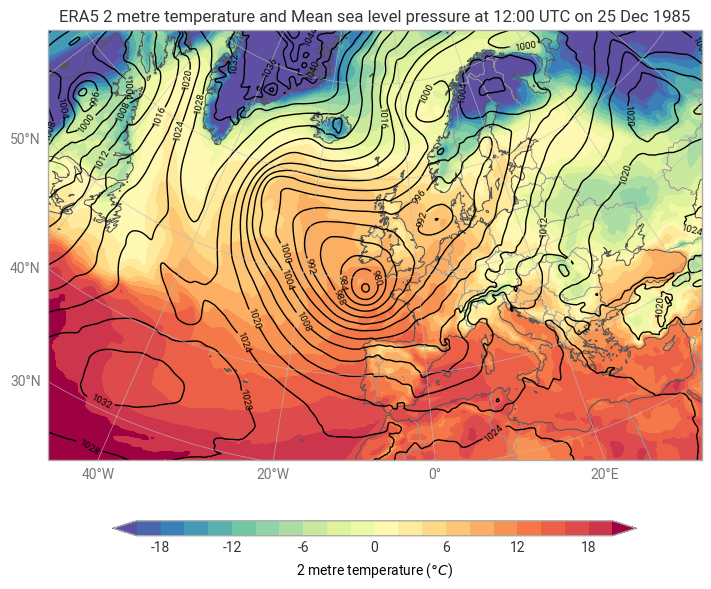

In [2]:
temp_style = ekp.styles.Style(
    levels=range(-20, 21, 2),
    colors="Spectral_r",
    units="celsius",
    extend="both",
)

pressure_style = ekp.styles.Contour(
    levels={"step": 4},
    colors="black",
    units="hPa",
    linewidths=[0.25, 0.25, 0.25, 0.75],
    labels=True,
    legend_style=None,
)

chart = ekp.Map(domain="North Atlantic")
chart.contourf(temperature, style=temp_style)
chart.contour(pressure, style=pressure_style)

# {time} is the same for both fields — it appears once
# {variable_name} differs — both names are listed
chart.title("ERA5 {variable_name} at {time:%H:%M UTC on %d %b %Y}")

# Each legend entry uses {variable_name} and {units} from its own layer
chart.legend(label="{variable_name} ({units})")

chart.coastlines()
chart.borders()
chart.gridlines()

chart.show()

### How the deduplication works

Look at the title that was generated.  earthkit-plots collects the metadata
from every layer plotted on the chart and resolves each format key as follows:

- **Shared values** (same across all layers) are shown **once**.  Here `{time}`
  resolves to a single date because both fields come from the same analysis
  time.
- **Differing values** are shown **as a list**, converted into human-readable form (i.e. "a, b and c").  Here
  `{variable_name}` lists both "2 metre temperature" and "Mean sea level
  pressure" because the two fields are different variables.

The same logic applies to legend labels, but there each label is resolved
independently per layer, so `{variable_name}` always expands to the name of
the single field it belongs to.

### Available format keys

Some commonly useful keys:

| Key | What it resolves to |
|---|---|
| `{variable_name}` | Human-readable variable name (`long_name`, `standard_name`, GRIB short name — whichever is found first) |
| `{units}` | Units after any conversion applied at plot time |
| `{time:%d %B %Y}` | Valid time, formatted with standard `strftime` codes |
| `{domain}` | Name of the map domain (named domains only) |
| `{crs}` | Name of the map projection |
| `{latitude:%Lt}` | Latitude with degree symbol and N/S direction |
| `{longitude:%Ln}` | Longitude with degree symbol and E/W direction |

### What's next?

The next notebook shows how to control map domains and projections.